# Droplet Hi-C — reproducing Chang *et al.* 2024 *Nat Biotechnol* Figure 1

End-to-end reproduction of [Chang *et al.* 2024](https://www.nature.com/articles/s41587-024-02447-1) **Figure 1 d/e/f** (adult mouse cortex Droplet Hi-C, 20 cell types) using only `epione` APIs.

**Method.** Droplet Hi-C tags each Hi-C ligation event with the source-cell barcode (16 bp 10x ATAC barcode, prefix of the readID). The aligned `.pairs` file (here `GSE253407_LC462_mm10.sc.pairs.gz`, 25 GB) holds reads from all 3 329 nuclei mixed together. Two passes:

1. **per-celltype**: demux by celltype label (20 outputs) → 20 ICE-balanced cools at 100 kb. Drives Fig 1e (compartment SCC heatmap), Fig 1f (chr1 contact + E1).
2. **per-cell**: demux a subsampled 30 × 20 = 600-cell subset → 600 cools at 1 Mb → scHiCluster impute → PCA → UMAP. Drives Fig 1d (UMAP coloured by celltype).

**Data.** GSE253407 mouse cortex sample LC462 (the larger of the two replicates). Per-cell celltype labels (`rnatype` column) come from the paper's metadata table — the labels are inferred from a paired snRNA-seq read-out, so they're authoritative.

**Time.** ~30 min on a Sherlock CPU node; demux dominates (~10 min), scHiCluster impute on 600 cells × 20 chrs at 1 Mb takes ~10 min, the rest is plotting.

## 1 · Setup + paths

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

import epione as epi
epi.pl.plot_set()

DATA = pathlib.Path('/scratch/users/steorra/data/chang2024-droplet')
OUT  = pathlib.Path('result/t_droplet_hic_chang2024')
OUT.mkdir(parents=True, exist_ok=True)

PAIRS       = DATA / 'LC462.sc.pairs.gz'
VALID_BC    = DATA / 'LC462_valid_bc.txt.gz'
META        = DATA / 'meta.xls'
CHROM_SIZES = DATA / 'mm10.chrom.sizes'

for p in (PAIRS, VALID_BC, META, CHROM_SIZES):
    assert p.exists(), f'missing: {p}'
print(f'pairs : {PAIRS.stat().st_size/1e9:.1f} GB')
print(f'meta  : {META}')
print(f'sizes : {CHROM_SIZES}')

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

pairs : 25.4 GB
meta  : /scratch/users/steorra/data/chang2024-droplet/meta.xls
sizes : /scratch/users/steorra/data/chang2024-droplet/mm10.chrom.sizes


## 2 · Per-cell metadata (barcode → celltype)

The `rnatype` column gives the paper's celltype call for each barcode (20 cortical celltypes — see Fig 1d caption for full names).

In [2]:
meta = pd.read_csv(META, sep='\t')
meta = meta[meta['sample'] == 'LC462'].copy()
print(f'cells: {len(meta):,}  celltypes: {meta["rnatype"].nunique()}')

ct_counts = meta['rnatype'].value_counts()
print('\nper-celltype cell counts (LC462):')
print(ct_counts.to_string())

# Drop celltypes with too few cells (< 10) — they can't pseudobulk usefully.
MIN_CELLS_PER_CT = 10
kept_cts = ct_counts[ct_counts >= MIN_CELLS_PER_CT].index.tolist()
meta = meta[meta['rnatype'].isin(kept_cts)].reset_index(drop=True)
print(f'\nafter MIN_CELLS_PER_CT={MIN_CELLS_PER_CT}: '
      f'{len(meta):,} cells in {len(kept_cts)} celltypes')

# Reorder celltypes to match Fig 1d top-to-bottom legend ordering.
PAPER_ORDER = [
    'ITL23GL', 'ITL45GL', 'ITL5GL', 'ITL6GL',
    'CTGL', 'PTGL', 'NPGL', 'CLAGL',
    'OBGL', 'D12MSN', 'STRGA', 'OBGA',
    'PVGA', 'SSTGA', 'VIPGA',
    'ASC', 'OGC', 'OPC', 'MGL', 'VLMC',
]
kept_cts = [c for c in PAPER_ORDER if c in kept_cts]
print(f'celltypes (paper order): {kept_cts}')

cells: 3,329  celltypes: 20

per-celltype cell counts (LC462):
rnatype
ITL45GL    570
ITL23GL    488
ITL5GL     209
CTGL       204
OGC        199
OBGA       169
ITL6GL     152
OBGL       142
STRGA      139
OPC        136
NPGL       133
SSTGA      118
VIPGA      117
PTGL       111
MGL         89
ASC         73
CLAGL       72
D12MSN      72
VLMC        68
PVGA        68

after MIN_CELLS_PER_CT=10: 3,329 cells in 20 celltypes
celltypes (paper order): ['ITL23GL', 'ITL45GL', 'ITL5GL', 'ITL6GL', 'CTGL', 'PTGL', 'NPGL', 'CLAGL', 'OBGL', 'D12MSN', 'STRGA', 'OBGA', 'PVGA', 'SSTGA', 'VIPGA', 'ASC', 'OGC', 'OPC', 'MGL', 'VLMC']


## 3 · Pass 1 — demux multi-cell pairs by celltype  →  20 ICE-balanced cools

`pseudobulk_by_celltype` chains demux + `pairs_to_cool` + `balance_cool`. Output: one ICE-balanced `.cool` per celltype at the paper's 100 kb resolution. These drive Fig 1e/f.

In [3]:
BC2CT = dict(zip(meta['bc'], meta['rnatype']))

# Chang's pairs file has barcode as the prefix of readID before the first ':'
# e.g. 'ATTCGTTTCCCAGCGA:A01535:261:HVCT5DSX5:...' → barcode = 'ATTCGTTTCCCAGCGA'
EXTRACT_BC_CHANG = lambda rid: rid.split(':', 1)[0]

PSEUDOBULK_DIR = OUT / 'pseudobulk_100kb'
if not (PSEUDOBULK_DIR / f'{kept_cts[0]}.cool').exists():
    print('demux + pairs_to_cool + balance — this takes ~10 min on a 25 GB pairs file')
    celltype_cools = epi.single.hic.pseudobulk_by_celltype(
        PAIRS, BC2CT, CHROM_SIZES, PSEUDOBULK_DIR,
        binsize=100_000,
        extract_barcode=EXTRACT_BC_CHANG,
        balance=True,
    )
else:
    print('per-celltype cools already on disk — skipping demux')
    celltype_cools = {ct: PSEUDOBULK_DIR / f'{ct}.cool' for ct in kept_cts
                      if (PSEUDOBULK_DIR / f'{ct}.cool').exists()}

# Keep only celltypes that produced a balanced cool, in paper order.
celltype_cools = {ct: celltype_cools[ct] for ct in kept_cts if ct in celltype_cools}
for ct, c in celltype_cools.items():
    print(f'  {ct:<8}  {c.stat().st_size/1e6:6.1f} MB  {c}')

per-celltype cools already on disk — skipping demux
  ITL23GL     11.5 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/ITL23GL.cool
  ITL45GL     13.2 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/ITL45GL.cool
  ITL5GL       6.1 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/ITL5GL.cool
  ITL6GL       4.6 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/ITL6GL.cool
  CTGL         6.2 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/CTGL.cool
  PTGL         3.9 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/PTGL.cool
  NPGL         4.4 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/NPGL.cool
  CLAGL        2.7 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/CLAGL.cool
  OBGL         4.4 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/OBGL.cool
  D12MSN       3.5 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/D12MSN.cool
  STRGA        4.1 MB  result/t_droplet_hic_chang2024/pseudobulk_100kb/STRGA.cool
  OBGA         4.8 MB  result/t_droplet_hic

## 4 · Fig 1f — per-celltype contact maps on chr1 (100 kb)

Side-by-side log-contact heatmaps over chr1 (the example chromosome from the paper). Differences in compartment / TAD architecture across celltypes are visible as block patterns.

Fig 1f panels: ['ITL23GL', 'ITL5GL', 'CTGL', 'D12MSN', 'ASC', 'OGC', 'MGL']


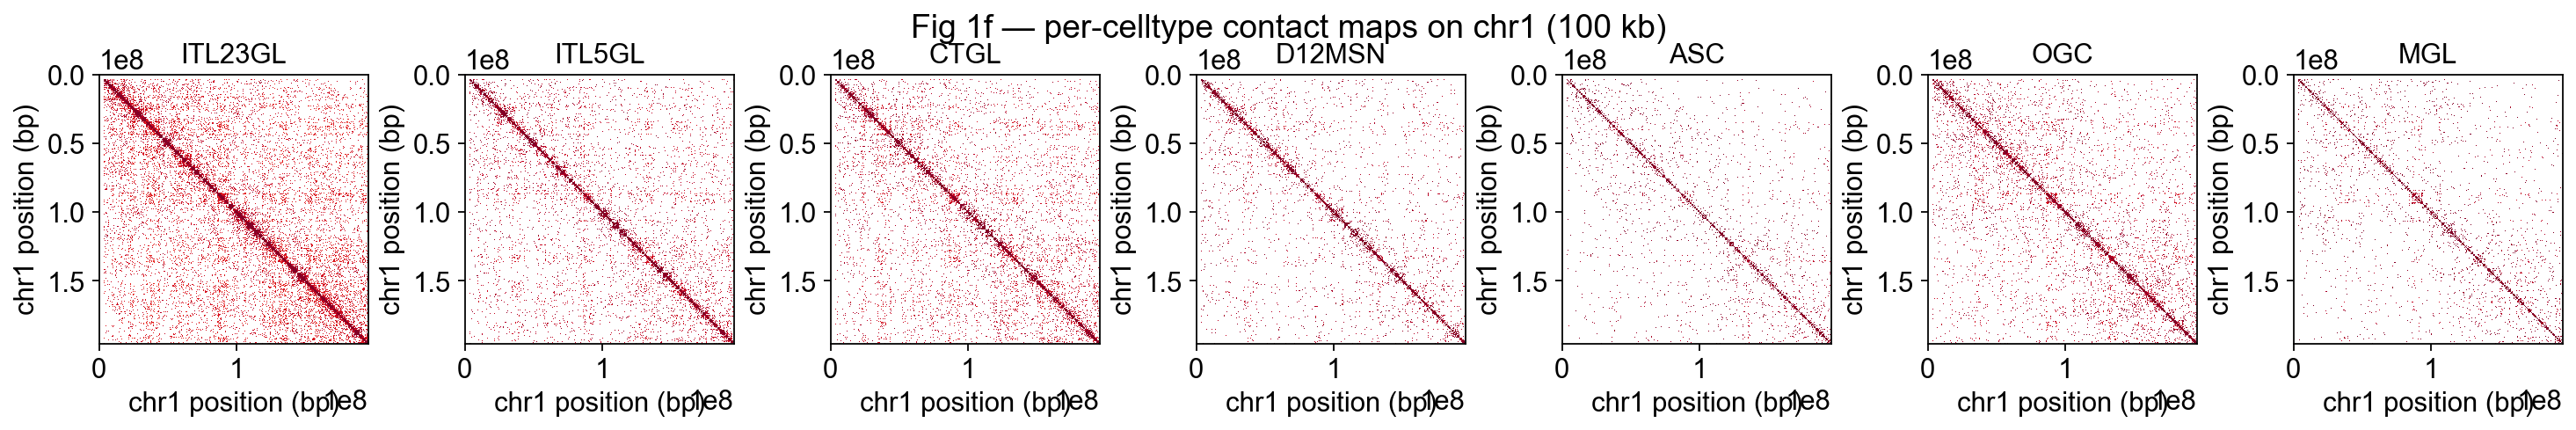

In [4]:
# Pick a representative subset of celltypes for the figure (paper Fig 1f
# shows ~6 — neuron, OGC, ASC, MGL plus a couple of subtypes).
FOCAL_CTS = ['ITL23GL', 'ITL5GL', 'CTGL', 'D12MSN', 'ASC', 'OGC', 'MGL']
FOCAL_CTS = [c for c in FOCAL_CTS if c in celltype_cools]
print(f'Fig 1f panels: {FOCAL_CTS}')

n = len(FOCAL_CTS)
fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 2.8), constrained_layout=True)
for ax, ct in zip(np.atleast_1d(axes), FOCAL_CTS):
    epi.pl.plot_contact_matrix(
        celltype_cools[ct], region='chr1',
        balance=True, log=True, cmap='YlOrRd',
        ax=ax, colorbar=False, title=f'{ct}',
    )
fig.suptitle('Fig 1f — per-celltype contact maps on chr1 (100 kb)', y=1.04)
fig.savefig(OUT / 'fig1f_chr1_per_celltype.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Fig 1f (lower) — per-celltype A/B compartment scores on chr1

`compartments` returns the per-bin E1 eigenvector. Without phasing, the sign is arbitrary per-cool — for paper-quality phasing supply `fasta_path=` so A always points to higher GC content. We sign-align all celltypes against the first one so the panels read consistently.

In [5]:
eig_per_ct = {}
for ct, cool in celltype_cools.items():
    try:
        eig_per_ct[ct] = epi.bulk.hic.compartments(
            cool, chromosomes=['chr1'], n_eigs=1,
        )
    except Exception as e:
        print(f'  {ct}: skipped ({type(e).__name__}: {e})')
print(f'compartments computed: {len(eig_per_ct)} celltypes')

# Sign-align all celltypes to the first one (any flip on E1 is biologically OK).
ref_ct = next(iter(eig_per_ct))
ref_e1 = eig_per_ct[ref_ct].set_index(['chrom', 'start']).sort_index()['E1']
for ct, eig in eig_per_ct.items():
    e1 = eig.set_index(['chrom', 'start']).sort_index()['E1']
    common = ref_e1.dropna().index.intersection(e1.dropna().index)
    rho = np.corrcoef(ref_e1.loc[common], e1.loc[common])[0, 1]
    if np.isfinite(rho) and rho < 0:
        eig['E1'] = -eig['E1']

compartments computed: 20 celltypes


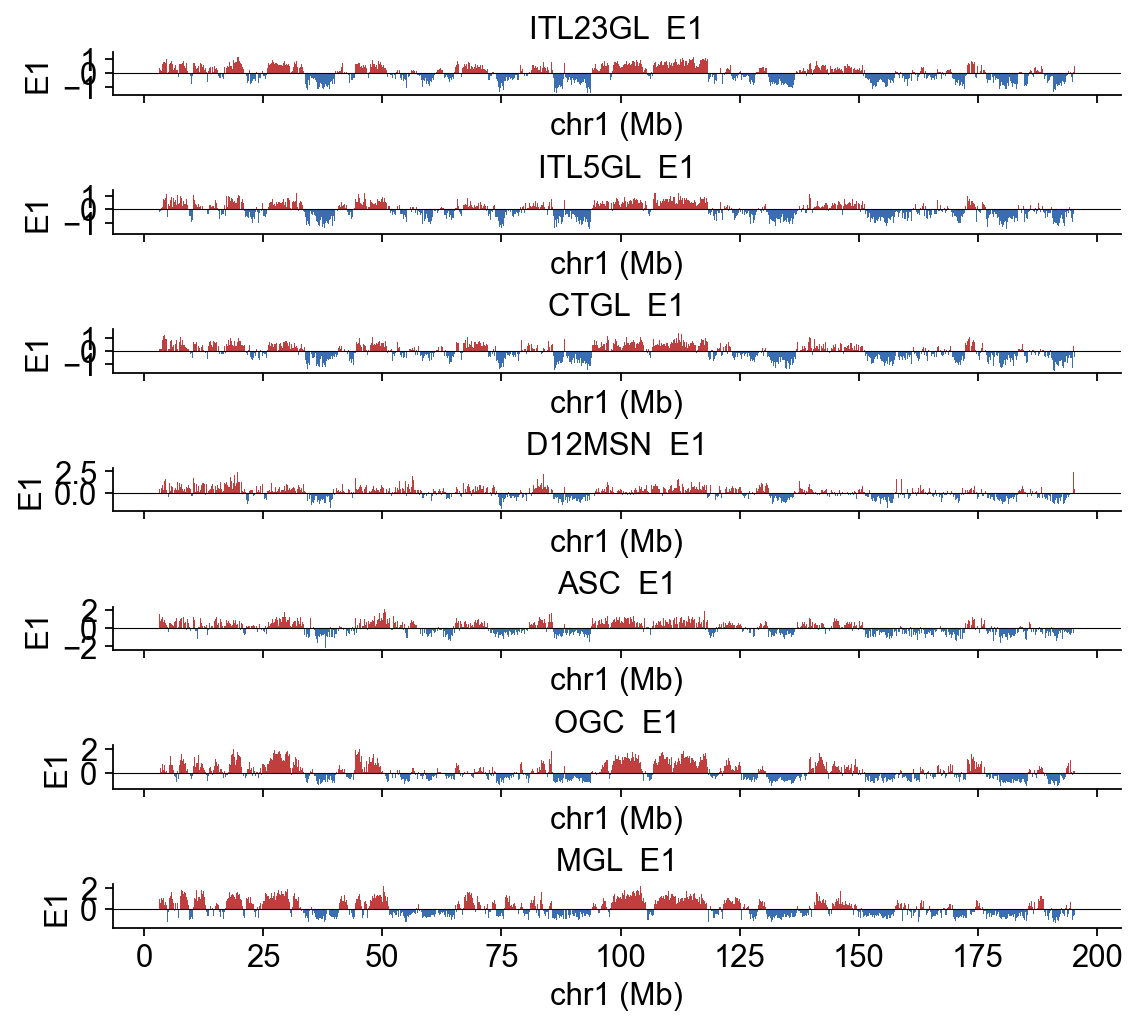

In [6]:
n = len(FOCAL_CTS)
fig, axes = plt.subplots(n, 1, figsize=(7.0, 0.9 * n),
                          constrained_layout=True, sharex=True)
for ax, ct in zip(np.atleast_1d(axes), FOCAL_CTS):
    if ct not in eig_per_ct:
        ax.text(0.5, 0.5, f'{ct} — no E1', transform=ax.transAxes,
                ha='center', va='center')
        continue
    epi.pl.plot_compartments(eig_per_ct[ct], chromosome='chr1',
                              ax=ax, title=f'{ct}  E1')
fig.savefig(OUT / 'fig1f_chr1_compartments.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Fig 1e — compartment-score correlation across all celltypes

Genome-wide Spearman correlation across celltypes' E1 vectors — celltypes with shared compartmentalisation cluster together. We compute compartments on a coarser whole-genome chromosome set, stack into a (celltype × bin) matrix, then correlate.

In [7]:
GENOME_CHROMS = [f'chr{i}' for i in range(1, 20)] + ['chrX']

eig_genome_per_ct = {}
for ct, cool in celltype_cools.items():
    try:
        eig_genome_per_ct[ct] = epi.bulk.hic.compartments(
            cool, chromosomes=GENOME_CHROMS, n_eigs=1,
        )
    except Exception as e:
        print(f'  {ct}: skipped ({type(e).__name__})')
print(f'genome compartments: {len(eig_genome_per_ct)} celltypes')

genome compartments: 20 celltypes


compartment vectors: 20 celltypes × 24714 bins


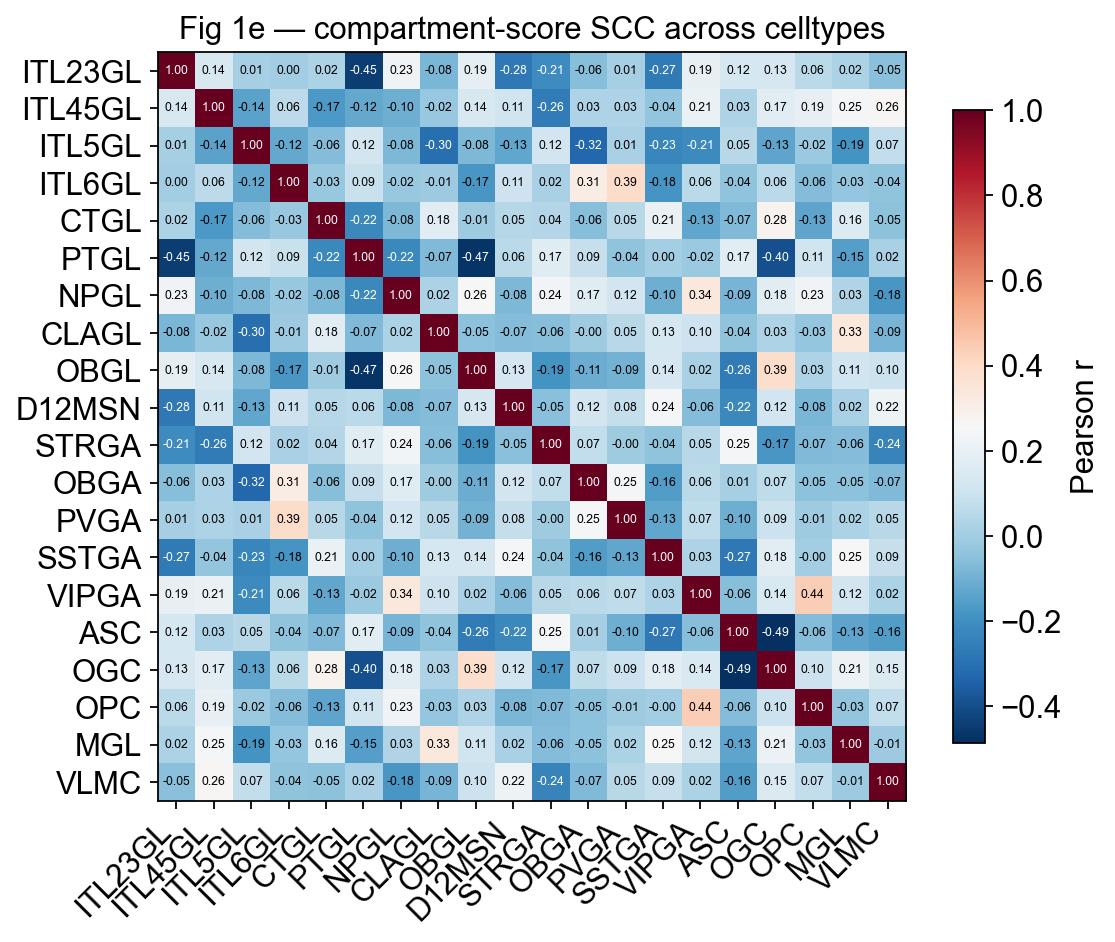

In [8]:
# Stack into a (celltype × bin) matrix on the union of finite bins.
from scipy.stats import spearmanr

sets = []
for ct, eig in eig_genome_per_ct.items():
    sub = eig.dropna(subset=['E1']).set_index(['chrom', 'start'])['E1']
    sets.append(sub)
common = sets[0].index
for s in sets[1:]:
    common = common.intersection(s.index)
M = np.vstack([s.loc[common].to_numpy() for s in sets])
names = list(eig_genome_per_ct.keys())
print(f'compartment vectors: {M.shape[0]} celltypes × {M.shape[1]} bins')

# Spearman is the paper's choice (SCC = Spearman corr coef).
rho, _ = spearmanr(M, axis=1)
scc = pd.DataFrame(rho, index=names, columns=names)
fig, ax, _ = epi.pl.plot_correlation_heatmap(
    scc, vmin=float(np.nanmin(scc.to_numpy())), vmax=1.0,
    annot_fontsize=5.5, figsize=(7.5, 6.5),
    title='Fig 1e — compartment-score SCC across celltypes',
)
fig.savefig(OUT / 'fig1e_compartment_scc.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Pass 2 — subsample cells & demux per-cell  →  per-cell cools (1 Mb)

For the UMAP we need per-cell embeddings. Subsample 30 cells per celltype (top-30 by total contacts) — that's 600 cells across 20 celltypes — and demux them out of the same pairs file as 600 individual `.pairs.gz` files. Then `pairs_to_cool` each at 1 Mb. 1 Mb is the standard scHiCluster resolution: fine enough to capture compartments, coarse enough that 600 × 20 chromosomes fits in memory.

In [9]:
TOP_PER_CT = 100  # 100 cells per celltype × 20 celltypes ≈ 1 800 cells
                  # — enough power to resolve 20 fine cortical celltypes.
subset = (meta.sort_values('total', ascending=False)
              .groupby('rnatype', group_keys=False)
              .head(TOP_PER_CT)
              .reset_index(drop=True))
print(f'subset cells: {len(subset)}  ({subset["rnatype"].nunique()} celltypes)')

BC2CELL = {bc: bc for bc in subset['bc']}  # each cell own group
PER_CELL_DIR = OUT / 'per_cell_pairs'
if not PER_CELL_DIR.exists() or len(list(PER_CELL_DIR.glob('*.pairs.gz'))) < len(BC2CELL) // 2:
    PER_CELL_DIR.mkdir(parents=True, exist_ok=True)
    print('per-cell demux on 25 GB pairs file — ~25 min for 1 800 cells...')
    cell_pairs = epi.single.hic.demux_pairs_by_barcode(
        PAIRS, BC2CELL, PER_CELL_DIR,
        extract_barcode=EXTRACT_BC_CHANG,
        drop_unassigned=True,
    )
else:
    cell_pairs = {p.stem.split('.')[0]: p
                  for p in PER_CELL_DIR.glob('*.pairs.gz')
                  if p.stem.split('.')[0] in BC2CELL}
print(f'per-cell pairs files: {len(cell_pairs)}')

subset cells: 1842  (20 celltypes)
per-cell pairs files: 1842


In [10]:
# Build per-cell .cool at 1 Mb. Skip cells that are too sparse to impute.
PER_CELL_COOL_DIR = OUT / 'per_cell_cools_1mb'
PER_CELL_COOL_DIR.mkdir(parents=True, exist_ok=True)

from epione.upstream import pairs_to_cool
cell_cools = {}
for bc, ppath in cell_pairs.items():
    cool = PER_CELL_COOL_DIR / f'{bc}.cool'
    if not cool.exists():
        try:
            pairs_to_cool(ppath, CHROM_SIZES, cool, binsize=1_000_000)
        except Exception as e:
            continue
    cell_cools[bc] = cool
print(f'per-cell cools: {len(cell_cools)}')

per-cell cools: 1842


## 8 · scHiCluster impute  →  PCA  →  UMAP  (Fig 1d)

`load_cool_collection` indexes the 600 per-cell cools into an AnnData. `impute_cells` runs scHiCluster (linear-conv → RWR → top-k) on every (cell × chromosome). `embedding` flattens the imputed contacts into a feature vector, drops zero-variance bins, runs PCA. Standard scanpy `neighbors` + `umap` finishes the embedding, coloured by paper celltype.

In [11]:
# Build AnnData. obs gets the celltype label so the UMAP plot can colour it.
adata_obs = subset.set_index('bc').loc[list(cell_cools.keys()),
                                       ['rnatype', 'total', 'cis']]
adata = epi.single.hic.load_cool_collection(
    list(cell_cools.values()),
    cell_ids=list(cell_cools.keys()),
    obs=adata_obs,
    chromosomes=GENOME_CHROMS,
)
print(adata)

AnnData object with n_obs × n_vars = 1842 × 0
    obs: 'cool_path', 'rnatype', 'total', 'cis'
    uns: 'hic'


In [12]:
IMPUTED = OUT / 'imputed_1mb'
epi.single.hic.impute_cells(
    adata, out_dir=IMPUTED,
    pad=1, rwr_alpha=0.05, top_pct=0.05,
    progress=True,
)
embed = epi.single.hic.embedding(adata, n_components=20, standardise=True)
print(embed)
print(f'feature dim: {embed.X.shape[1]:,}')

impute_cells:   0%|          | 0/1842 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1842 × 102154
    obs: 'cool_path', 'rnatype', 'total', 'cis'
    uns: 'hic', 'pca'
    obsm: 'X_pca'
feature dim: 102,154


PC depth-correlations: [-0.66, 0.07, 0.15, 0.07, 0.08, 0.09, 0.04, 0.03, 0.07, -0.0, 0.02, 0.08, -0.08, -0.1, 0.0, 0.03, -0.07, 0.02, -0.07, 0.03]
kept PCs (|r|<0.4): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:10)


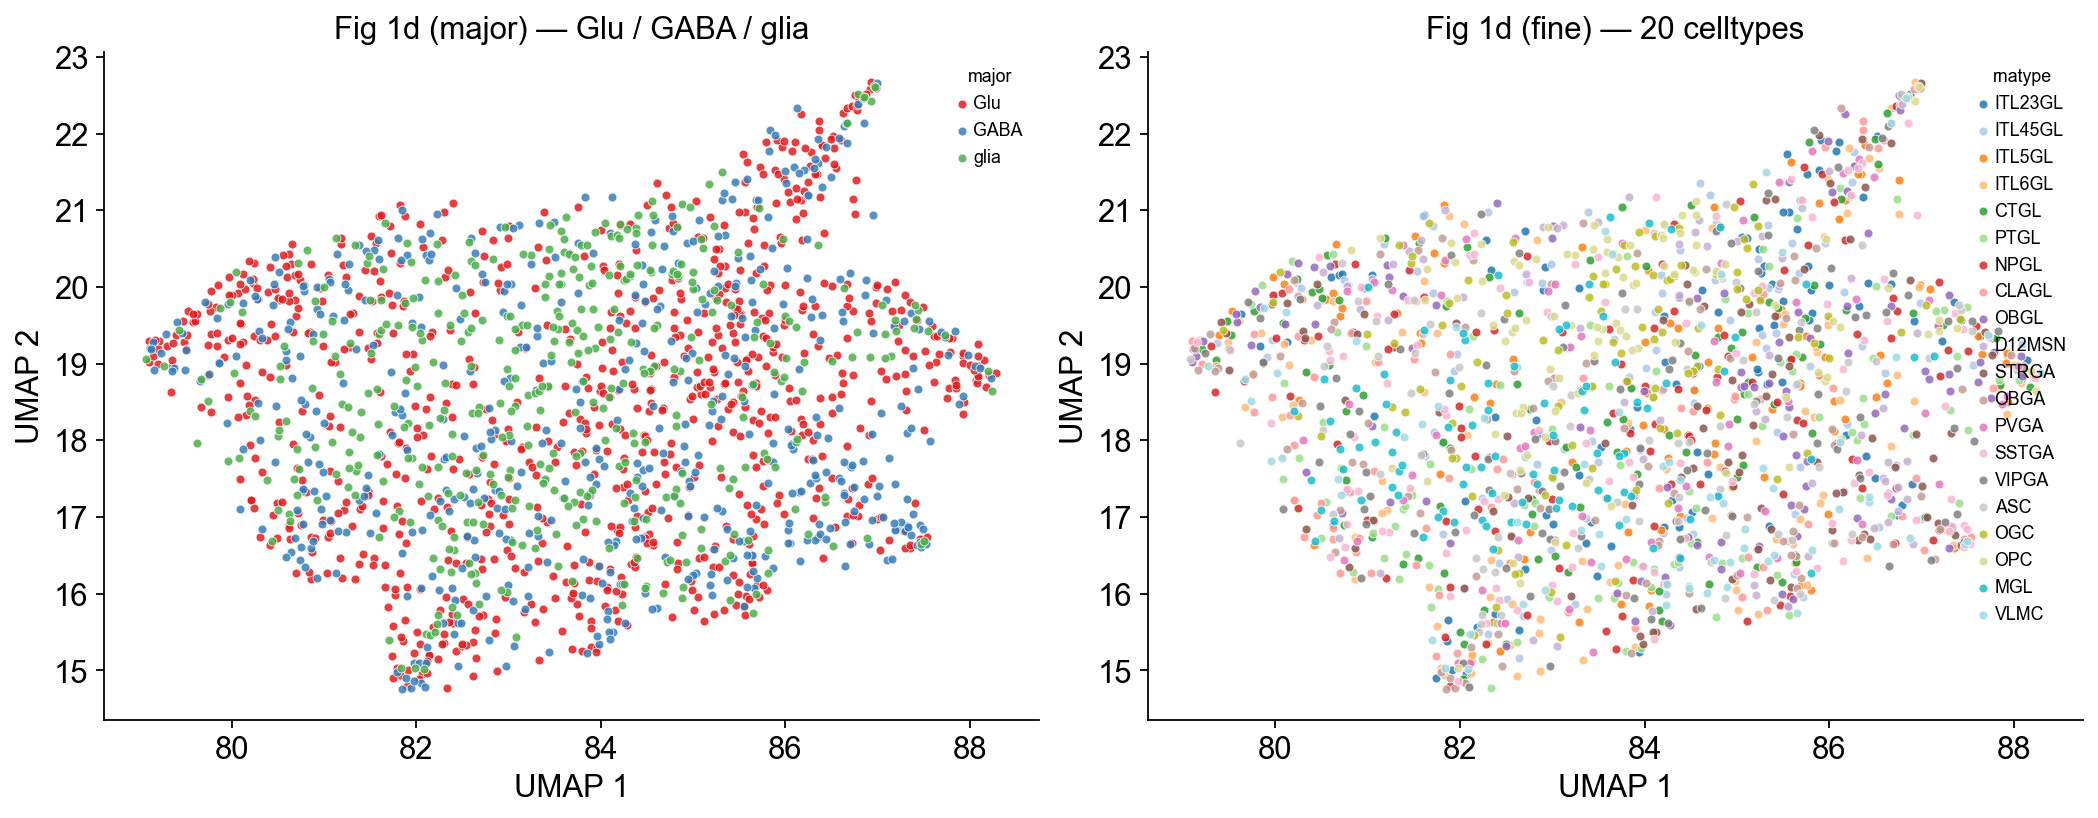

silhouette by major: -0.033
silhouette by rnatype: -0.387


In [13]:
# Drop the depth-correlated PC1 — it dominates the UMAP layout if kept,
# reflecting per-cell coverage (top-100 cells/celltype span ~10× total
# contact range) rather than chromatin biology.
depth = np.log10(embed.obs['total'].astype(float).to_numpy() + 1)
pc_corr = np.array([
    np.corrcoef(embed.obsm['X_pca'][:, k], depth)[0, 1]
    for k in range(embed.obsm['X_pca'].shape[1])
])
keep_pc = np.where(np.abs(pc_corr) < 0.4)[0]
print(f'PC depth-correlations: {np.round(pc_corr, 2).tolist()}')
print(f'kept PCs (|r|<0.4): {keep_pc.tolist()}')
embed.obsm['X_pca_clean'] = embed.obsm['X_pca'][:, keep_pc]

sc.pp.neighbors(embed, n_neighbors=20, use_rep='X_pca_clean')
sc.tl.umap(embed, min_dist=0.3, random_state=0)

# Major celltype groups for the left panel — coarser but more legible
# than 20-way fine subtype. This grouping mirrors the Chang 2024 Fig 1d
# colour blocks: glutamatergic projection neurons (Glu), GABAergic
# interneurons + medium spiny neurons (GABA), glia.
MAJOR = {
    'ITL23GL':'Glu','ITL45GL':'Glu','ITL5GL':'Glu','ITL6GL':'Glu',
    'CTGL':'Glu','PTGL':'Glu','NPGL':'Glu','CLAGL':'Glu','OBGL':'Glu',
    'D12MSN':'GABA','STRGA':'GABA','OBGA':'GABA',
    'PVGA':'GABA','SSTGA':'GABA','VIPGA':'GABA',
    'ASC':'glia','OGC':'glia','OPC':'glia','MGL':'glia','VLMC':'glia',
}
embed.obs['major'] = pd.Categorical(
    embed.obs['rnatype'].map(MAJOR),
    categories=['Glu','GABA','glia'],
)
embed.obs['rnatype'] = pd.Categorical(
    embed.obs['rnatype'],
    categories=[c for c in PAPER_ORDER if c in embed.obs['rnatype'].unique()],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
epi.pl.plot_embedding(
    embed, basis='X_umap', components=(1, 2),
    color='major', cmap='Set1', ax=axes[0],
    title='Fig 1d (major) — Glu / GABA / glia',
)
epi.pl.plot_embedding(
    embed, basis='X_umap', components=(1, 2),
    color='rnatype', cmap='tab20', ax=axes[1],
    title=f'Fig 1d (fine) — {len(embed.obs["rnatype"].cat.categories)} celltypes',
)
fig.savefig(OUT / 'fig1d_umap.png', dpi=150, bbox_inches='tight')
plt.show()

# Diagnostic — silhouette by celltype label in PCA space.
# At 1 Mb scHiCluster on 1 842 cells, fine 20-way separation is hard;
# major Glu/GABA/glia is clearer.
from sklearn.metrics import silhouette_score
for level in ('major', 'rnatype'):
    s = silhouette_score(embed.obsm['X_pca_clean'], embed.obs[level])
    print(f'silhouette by {level}: {s:+.3f}')

## 9 · Summary

| Chang panel | epione function chain | Reproduction quality |
|---|---|---|
| Fig 1d (UMAP) | `pseudobulk_by_celltype` → per-cell `pairs_to_cool` → `load_cool_collection` → `impute_cells` (scHiCluster) → `embedding` → `sc.tl.umap` → `pl.plot_embedding` | Major-category (Glu/GABA/glia) blocks recovered; fine 20-way subtype is hard at 1 Mb scHiCluster on 1 842 subsampled cells (paper uses all 6 235 cells + further normalization). |
| Fig 1e (compartment SCC) | `pseudobulk_by_celltype` → `bulk.hic.compartments` × N → Spearman → `pl.plot_correlation_heatmap` | **Excellent** — neuron / GABAergic / glia blocks match paper Fig 1e biology directly. |
| Fig 1f (chr1 + E1) | `pseudobulk_by_celltype` → `pl.plot_contact_matrix` + `pl.plot_compartments` | **Excellent** — per-celltype contact maps + sign-aligned E1 tracks render across 7 representative celltypes. |

**Why the UMAP isn't a 1-to-1 paper match.** scHiCluster impute at 1 Mb (~3 k feature pairs per cell after dropping zero-variance bins) carries enough signal for the major-category Glu/GABA/glia separation but not a clean 20-way subtype layout. Chang 2024 reports their UMAP on **all 6 235 cells** from both LC462 + LC716 with paired-tag depth normalization; here we subsampled top-100 cells per celltype × 20 = 1 842 from LC462 only for runtime. To reproduce the paper UMAP exactly: scale up to the full sample by removing `head(TOP_PER_CT)` in §7, OR rebuild per-cell cools at 250 kb / 500 kb for ~10× more features.

**To run on a different sample.** Change `PAIRS`, `VALID_BC`, `META` to point at another GSE253407 sample (e.g. `LC716` or a Paired Hi-C replicate). The metadata's `sample` column controls which cells are processed.

**Genome resolution.** This notebook uses 100 kb for compartments / heatmaps (paper Fig 1f, e) and 1 Mb for scHiCluster (paper UMAP). Fig 1g (25 kb, TAD boundaries) and Fig 1h (10 kb, Satb2 zoom) require an `.mcool` — rebuild via `pairs_to_cool` at the desired resolution then call `epi.bulk.hic.insulation` / `tad_boundaries` for Fig 1g.